# <center> <img src="../img/ITESOLogo.png" alt="ITESO" width="480" height="130"> </center>
# <center> **Departamento de Electrónica, Sistemas e Informática** </center>
---
## <center> **Big Data** </center>
---
### <center> **Spring 2026** </center>
---
### <center> **Examples on Structured Streaming (files)** </center>
---
**Profesor**: Pablo Camarillo Ramirez

Santiago Elí Jiménez Aguilar
Luis Eduardo Gonzalez Gloria

## Description

- **Producer**. You need to create a script that produces random log entries (using bash or python). This script should be part of your module under the lib directory.
- **Consumer Application**. Build a Jupyter Notebook with a data pipeline using structured streaming that monitors a directory for simulated server log files, analyzes error patterns in real time, and filters alerts for ERROR entries. The sink (destination) should be the output console.
- Submit the PDF version of the consumer application (Jupyter Notebook). In the Notebook should be visible at least three micro batches of the streaming.

## Log entry example:

2026-03-20 10:00:00 | WARN  | Disk usage 85% | server-node-1<br>
2026-03-20 10:00:05 | ERROR | 500 Internal Server Error | server-node-2<br>
2026-03-20 10:00:10 | INFO  | User login successful | server-node-1

# Create SparkSession

In [1]:
from spark_utils import SparkUtils

su = SparkUtils("Structured Streaming with Files",
                   master_url="spark://spark-master:7077")

su.spark

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/07 00:51:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Create a data stream from a local socket

### Connect Spark to the socket

In [2]:
!ls /opt/spark/work-dir/data/streaming/logs/

In [ ]:
import pyspark.sql.functions as F
from pathlib import Path
import shutil

logs_schema = SparkUtils.generate_schema([("raw_line", "string")])

input_path = "/opt/spark/work-dir/data/streaming/logs/"

# Create the stream
logs_df = (su.spark.readStream
            .format("text")
            .option("maxFilesPerTrigger", 1) # Let's process one file at a time
            .schema(logs_schema)
            .load(input_path))

# Transform original dataframe
parsed_df = (
    logs_df
    .withColumn("parts",     F.split(F.col("raw_line"), r" \| "))
    .withColumn("timestamp", F.to_timestamp(F.col("parts")[0], "yyyy-MM-dd HH:mm:ss"))
    .withColumn("level",     F.trim(F.col("parts")[1]))
    .withColumn("message",   F.trim(F.col("parts")[2]))
    .withColumn("server",    F.trim(F.col("parts")[3]))
    .drop("parts", "raw_line")               # keep only the clean columns
    .filter(F.col("timestamp").isNotNull())  # skip malformed lines
)

# Let's create a summary
summary_df = (
    parsed_df
    .groupBy("server", "level")
    .count()
    .orderBy("server", "level")
)

# Clean checkpoint
checkpoint_path = "/opt/spark/work-dir/checkpoints/logs_checkpoint"
dir_path = Path(checkpoint_path)
if dir_path.exists() and dir_path.is_dir():
    shutil.rmtree(dir_path)

# Write stream in the destination
query_events = (
    parsed_df.writeStream
    .outputMode("append")        # append: show new rows only
    .format("console")
    .option("truncate", False)   # don't cut off long messages
    .option("numRows", 20)
    .option("checkpointLocation", checkpoint_path)
    .queryName("parsed_logs")
    .start()
)

query_summary = (
    summary_df.writeStream
    .outputMode("complete")
    .format("console")
    .option("truncate", False)
    .queryName("summary_logs")
    .start()
)

print("   Press Ctrl+C to stop.\n")
su.spark.streams.awaitAnyTermination()


26/04/07 00:52:00 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
26/04/07 00:52:00 WARN ResolveWriteToStream: Temporary checkpoint location created which is deleted normally when the query didn't fail: /tmp/temporary-8b4b1353-f397-4d6f-9e97-895d075144ce. If it's required to delete it under any circumstances, please set spark.sql.streaming.forceDeleteTempCheckpointLocation to true. Important to know deleting temp checkpoint folder is best effort.
26/04/07 00:52:00 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.


   Press Ctrl+C to stop.



-------------------------------------------
Batch: 0
-------------------------------------------
+-------------------+-----+------------------------------------+-------------+
|timestamp          |level|message                             |server       |
+-------------------+-----+------------------------------------+-------------+
|2026-04-07 01:03:35|ERROR|Authentication failed               |server-node-3|
|2026-04-07 01:03:45|WARN |Response time above threshold       |server-node-2|
|2026-04-07 01:03:48|INFO |User login successful               |server-node-2|
|2026-04-07 01:03:49|INFO |Cache cleared                       |server-node-2|
|2026-04-07 01:03:56|INFO |User login successful               |server-node-2|
|2026-04-07 01:04:03|WARN |Certificate expires in 7 days       |server-node-4|
|2026-04-07 01:04:04|WARN |Memory usage 90%                    |server-node-1|
|2026-04-07 01:04:14|INFO |Backup completed successfully       |server-node-4|
|2026-04-07 01:04:23|INFO |Service

-------------------------------------------
Batch: 0
-------------------------------------------
+-------------+-----+-----+
|server       |level|count|
+-------------+-----+-----+
|server-node-1|ERROR|4    |
|server-node-1|INFO |2    |
|server-node-1|WARN |5    |
|server-node-2|ERROR|6    |
|server-node-2|INFO |4    |
|server-node-2|WARN |3    |
|server-node-3|ERROR|3    |
|server-node-3|INFO |4    |
|server-node-3|WARN |4    |
|server-node-4|ERROR|3    |
|server-node-4|INFO |3    |
|server-node-4|WARN |3    |
|server-node-5|ERROR|2    |
|server-node-5|INFO |2    |
|server-node-5|WARN |2    |
+-------------+-----+-----+

-------------------------------------------
Batch: 1
-------------------------------------------
+-------------------+-----+------------------------------------+-------------+
|timestamp          |level|message                             |server       |
+-------------------+-----+------------------------------------+-------------+
|2026-04-07 01:03:50|INFO |Health ch

-------------------------------------------
Batch: 1
-------------------------------------------
+-------------+-----+-----+
|server       |level|count|
+-------------+-----+-----+
|server-node-1|ERROR|9    |
|server-node-1|INFO |3    |
|server-node-1|WARN |7    |
|server-node-2|ERROR|11   |
|server-node-2|INFO |7    |
|server-node-2|WARN |6    |
|server-node-3|ERROR|4    |
|server-node-3|INFO |12   |
|server-node-3|WARN |6    |
|server-node-4|ERROR|10   |
|server-node-4|INFO |5    |
|server-node-4|WARN |6    |
|server-node-5|ERROR|5    |
|server-node-5|INFO |6    |
|server-node-5|WARN |3    |
+-------------+-----+-----+

-------------------------------------------
Batch: 2
-------------------------------------------
+-------------------+-----+-----------------------------+-------------+
|timestamp          |level|message                      |server       |
+-------------------+-----+-----------------------------+-------------+
|2026-04-07 01:04:05|INFO |Backup completed successfully|

-------------------------------------------
Batch: 2
-------------------------------------------
+-------------+-----+-----+
|server       |level|count|
+-------------+-----+-----+
|server-node-1|ERROR|13   |
|server-node-1|INFO |7    |
|server-node-1|WARN |11   |
|server-node-2|ERROR|12   |
|server-node-2|INFO |11   |
|server-node-2|WARN |10   |
|server-node-3|ERROR|7    |
|server-node-3|INFO |15   |
|server-node-3|WARN |9    |
|server-node-4|ERROR|13   |
|server-node-4|INFO |7    |
|server-node-4|WARN |8    |
|server-node-5|ERROR|7    |
|server-node-5|INFO |14   |
|server-node-5|WARN |6    |
+-------------+-----+-----+

-------------------------------------------
Batch: 3
-------------------------------------------
+-------------------+-----+------------------------------------+-------------+
|timestamp          |level|message                             |server       |
+-------------------+-----+------------------------------------+-------------+
|2026-04-07 01:08:00|INFO |User logi

-------------------------------------------
Batch: 3
-------------------------------------------
+-------------+-----+-----+
|server       |level|count|
+-------------+-----+-----+
|server-node-1|ERROR|16   |
|server-node-1|INFO |7    |
|server-node-1|WARN |15   |
|server-node-2|ERROR|14   |
|server-node-2|INFO |12   |
|server-node-2|WARN |13   |
|server-node-3|ERROR|10   |
|server-node-3|INFO |26   |
|server-node-3|WARN |12   |
|server-node-4|ERROR|13   |
|server-node-4|INFO |11   |
|server-node-4|WARN |14   |
|server-node-5|ERROR|9    |
|server-node-5|INFO |19   |
|server-node-5|WARN |9    |
+-------------+-----+-----+

-------------------------------------------
Batch: 4
-------------------------------------------
+-------------------+-----+------------------------------------+-------------+
|timestamp          |level|message                             |server       |
+-------------------+-----+------------------------------------+-------------+
|2026-04-07 01:08:15|WARN |Memory us

-------------------------------------------
Batch: 4
-------------------------------------------
+-------------+-----+-----+
|server       |level|count|
+-------------+-----+-----+
|server-node-1|ERROR|22   |
|server-node-1|INFO |10   |
|server-node-1|WARN |18   |
|server-node-2|ERROR|15   |
|server-node-2|INFO |12   |
|server-node-2|WARN |17   |
|server-node-3|ERROR|15   |
|server-node-3|INFO |32   |
|server-node-3|WARN |15   |
|server-node-4|ERROR|15   |
|server-node-4|INFO |12   |
|server-node-4|WARN |17   |
|server-node-5|ERROR|13   |
|server-node-5|INFO |23   |
|server-node-5|WARN |14   |
+-------------+-----+-----+

-------------------------------------------
Batch: 5
-------------------------------------------
+-------------------+-----+------------------------------------+-------------+
|timestamp          |level|message                             |server       |
+-------------------+-----+------------------------------------+-------------+
|2026-04-07 01:08:30|WARN |Memory us

In [ ]:
su.spark.stop()

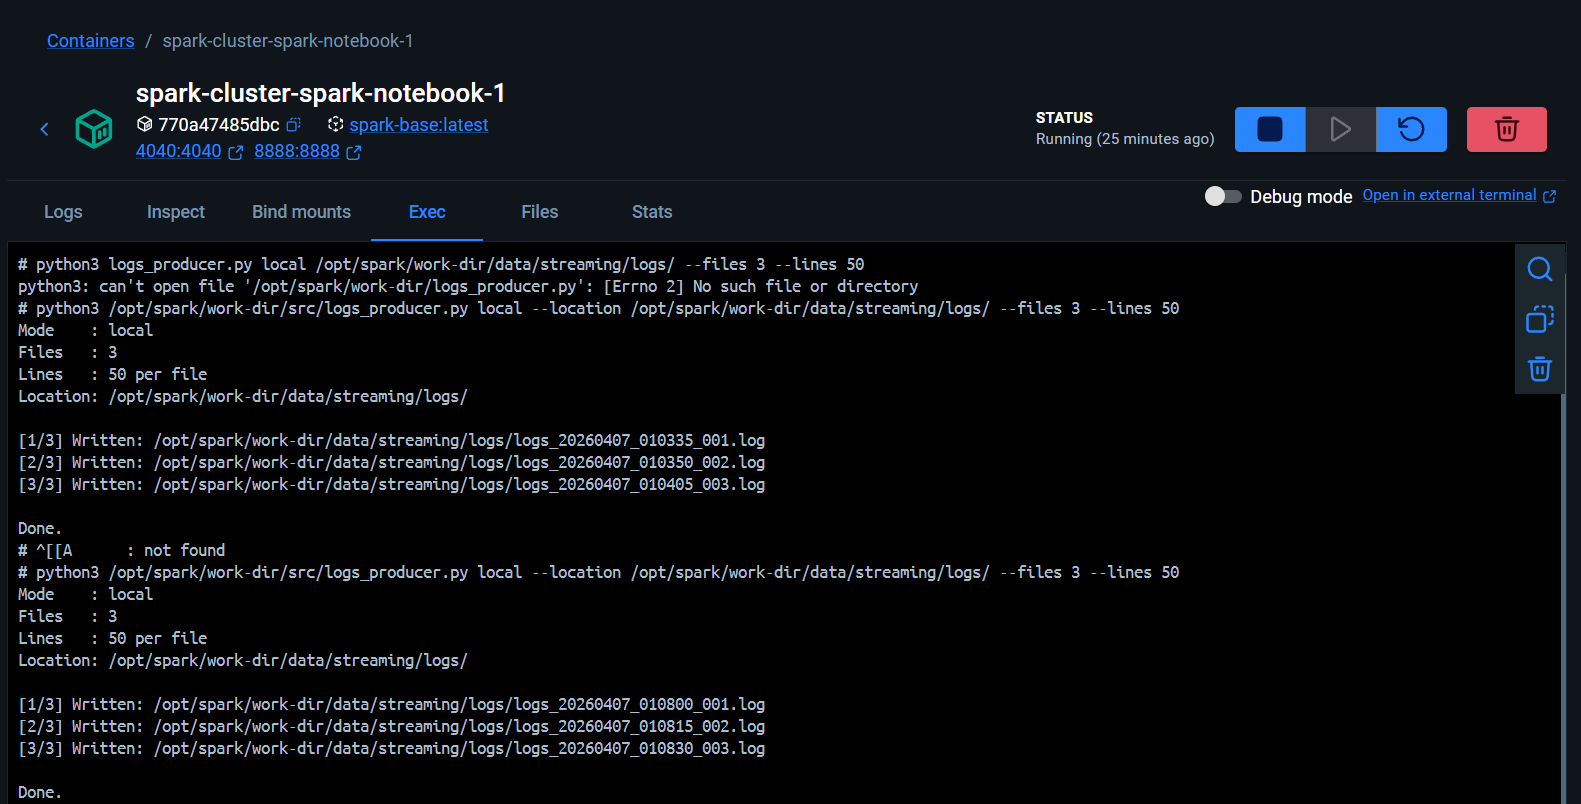